In [50]:
# Importando os pacotes que serão utilizados

# Para manipulação e tratamento dos dados
import numpy as np
import pandas as pd 
import time #utilizada para funções de tempo
import matplotlib.pyplot as plt #Utilizada para gráficos
import seaborn as sns #Utilizada para gráficos

# Modelo de churn baseado no comportamento de transições dos clientes 

In [51]:
df_original = pd.read_csv("abt_churn.csv")

# Exploração dos dados

In [52]:
df_original.head()

,dtRef,idUsuario,qtdeTransacoes,qtdeDias,mediaTransacoesDias,saldoPontos,qtdePontosPos,qtdePontosNeg,qtdeDiasUltimaTransacao,qtdeDiasPrimeiraTransacao,...,saldoPontosD28,qtdePontosPosD28,qtdePontosNegD28,propAvgQtdeTransacoes,propAvgQtdeDias,propAvgMediaTransacoesDias,propAvgSaldoPontos,propAvgQtdePontosPos,propAvgQtdePontosNeg,flagChurn
0,2024-06-01,000ff655-fa9f-4baa-a108-47f581ec52a1,266,27,9.851852,635,2635,-2000,1.0,89.0,...,151,151,0,3.889781,3.278281,2.135602,1.516314,4.101926,8.944444,1
1,2024-10-01,000ff655-fa9f-4baa-a108-47f581ec52a1,268,28,9.571429,686,2686,-2000,4.0,211.0,...,51,51,0,3.309865,2.567615,2.328737,1.288278,2.920954,5.167037,1
2,2024-04-01,000ff655-fa9f-4baa-a108-47f581ec52a1,188,11,17.090909,275,1275,-1000,3.0,28.0,...,275,1275,-1000,3.805468,1.820201,3.739048,0.798622,2.634551,7.162791,0
3,2024-05-01,000ff655-fa9f-4baa-a108-47f581ec52a1,262,24,10.916667,484,2484,-2000,2.0,58.0,...,107,1107,-1000,4.246216,3.255244,2.322640,1.275749,4.275765,9.922414,0
4,2024-08-01,001749bd-37b5-4b1e-8111-f9fbba90f530,1,1,1.000000,50,50,0,21.0,21.0,...,50,50,0,0.013317,0.103973,0.236635,0.104533,0.063302,0.000000,1


In [53]:
df_original.tail()

,dtRef,idUsuario,qtdeTransacoes,qtdeDias,mediaTransacoesDias,saldoPontos,qtdePontosPos,qtdePontosNeg,qtdeDiasUltimaTransacao,qtdeDiasPrimeiraTransacao,...,saldoPontosD28,qtdePontosPosD28,qtdePontosNegD28,propAvgQtdeTransacoes,propAvgQtdeDias,propAvgMediaTransacoesDias,propAvgSaldoPontos,propAvgQtdePontosPos,propAvgQtdePontosNeg,flagChurn
5491,2025-02-01,ff07d926-f09e-420b-bebf-3dba02ae5dff,3,1,3.0,52,52,0,11.0,11.0,...,52,52,0,0.036148,0.085733,0.744779,0.098768,0.053507,0.0,0
5492,2025-03-01,ff07d926-f09e-420b-bebf-3dba02ae5dff,5,2,2.5,54,54,0,1.0,39.0,...,2,2,0,0.061868,0.173459,0.626703,0.104061,0.057551,0.0,1
5493,2024-06-01,ff1ceaef-650c-422b-bdc3-6984e29e7aa5,15,3,5.0,162,162,0,17.0,19.0,...,162,162,0,0.219349,0.364253,1.083858,0.386839,0.252187,0.0,1
5494,2025-03-01,ff2cabd3-3316-4b3f-8494-c25f95e90524,8,1,8.0,57,57,0,19.0,19.0,...,57,57,0,0.098988,0.086730,2.005448,0.109843,0.060749,0.0,1
5495,2024-06-01,ff4909ad-4e52-4767-a6fc-0fbd76e37857,1,1,1.0,50,50,0,24.0,24.0,...,50,50,0,0.014623,0.121418,0.216772,0.119395,0.077835,0.0,1


In [54]:
df_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5496 entries, 0 to 5495
Data columns (total 43 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   dtRef                       5496 non-null   object 
 1   idUsuario                   5496 non-null   object 
 2   qtdeTransacoes              5496 non-null   int64  
 3   qtdeDias                    5496 non-null   int64  
 4   mediaTransacoesDias         5496 non-null   float64
 5   saldoPontos                 5496 non-null   int64  
 6   qtdePontosPos               5496 non-null   int64  
 7   qtdePontosNeg               5496 non-null   int64  
 8   qtdeDiasUltimaTransacao     5496 non-null   float64
 9   qtdeDiasPrimeiraTransacao   5496 non-null   float64
 10  qtdSkuDistintos             5496 non-null   int64  
 11  qtdeChatMessage             5496 non-null   int64  
 12  qtdePresença                5496 non-null   int64  
 13  qtdeTrocaStreamElements     5496 

In [55]:
df_original.isnull().sum() * 100 / len(df_original)

dtRef                         0.0
idUsuario                     0.0
qtdeTransacoes                0.0
qtdeDias                      0.0
mediaTransacoesDias           0.0
saldoPontos                   0.0
qtdePontosPos                 0.0
qtdePontosNeg                 0.0
qtdeDiasUltimaTransacao       0.0
qtdeDiasPrimeiraTransacao     0.0
qtdSkuDistintos               0.0
qtdeChatMessage               0.0
qtdePresença                  0.0
qtdeTrocaStreamElements       0.0
qtdeChurn                     0.0
qtdePonei                     0.0
qtdeAirflowLover              0.0
qtdePresencaStreak            0.0
qtdeDailyLoot                 0.0
qtdeRLover                    0.0
qtdeVendaItemRPG              0.0
qtdeTransacoesD7              0.0
qtdeDiasD7                    0.0
saldoPontosD7                 0.0
qtdePontosPosD7               0.0
qtdePontosNegD7               0.0
qtdeTransacoesD14             0.0
qtdeDiasD14                   0.0
saldoPontosD14                0.0
qtdePontosPosD

In [56]:
df_original.duplicated().sum()

0

In [57]:
# Verificando Valores Únicos
df_original.nunique()

dtRef                           14
idUsuario                     2251
qtdeTransacoes                 759
qtdeDias                       217
mediaTransacoesDias           1941
saldoPontos                   1956
qtdePontosPos                 2270
qtdePontosNeg                  151
qtdeDiasUltimaTransacao         27
qtdeDiasPrimeiraTransacao      377
qtdSkuDistintos                 16
qtdeChatMessage                682
qtdePresença                   200
qtdeTrocaStreamElements         40
qtdeChurn                      106
qtdePonei                       34
qtdeAirflowLover                10
qtdePresencaStreak              42
qtdeDailyLoot                   27
qtdeRLover                       6
qtdeVendaItemRPG                19
qtdeTransacoesD7               152
qtdeDiasD7                       8
saldoPontosD7                  561
qtdePontosPosD7                504
qtdePontosNegD7                 16
qtdeTransacoesD14              209
qtdeDiasD14                     15
saldoPontosD14      

In [58]:
#from ydata_profiling import ProfileReport

#profile = ProfileReport(df_original)

#profile.to_file("previsao_churn.html")

In [59]:
# Carregar variaveis para plot
# Pegaremos a partir da variavel 1 porque o ID_CLIENTE não iremos utilizar
variaveis_numericas = []
for i in df_original.columns[1:24].tolist():
        if df_original.dtypes[i] == 'int64' or df_original.dtypes[i] == 'float64':            
            print(i, ':' , df_original.dtypes[i]) 
            variaveis_numericas.append(i)    

qtdeTransacoes : int64
qtdeDias : int64
mediaTransacoesDias : float64
saldoPontos : int64
qtdePontosPos : int64
qtdePontosNeg : int64
qtdeDiasUltimaTransacao : float64
qtdeDiasPrimeiraTransacao : float64
qtdSkuDistintos : int64
qtdeChatMessage : int64
qtdePresença : int64
qtdeTrocaStreamElements : int64
qtdeChurn : int64
qtdePonei : int64
qtdeAirflowLover : int64
qtdePresencaStreak : int64
qtdeDailyLoot : int64
qtdeRLover : int64
qtdeVendaItemRPG : int64
qtdeTransacoesD7 : int64
qtdeDiasD7 : int64
saldoPontosD7 : int64


In [60]:
len(variaveis_numericas)

22

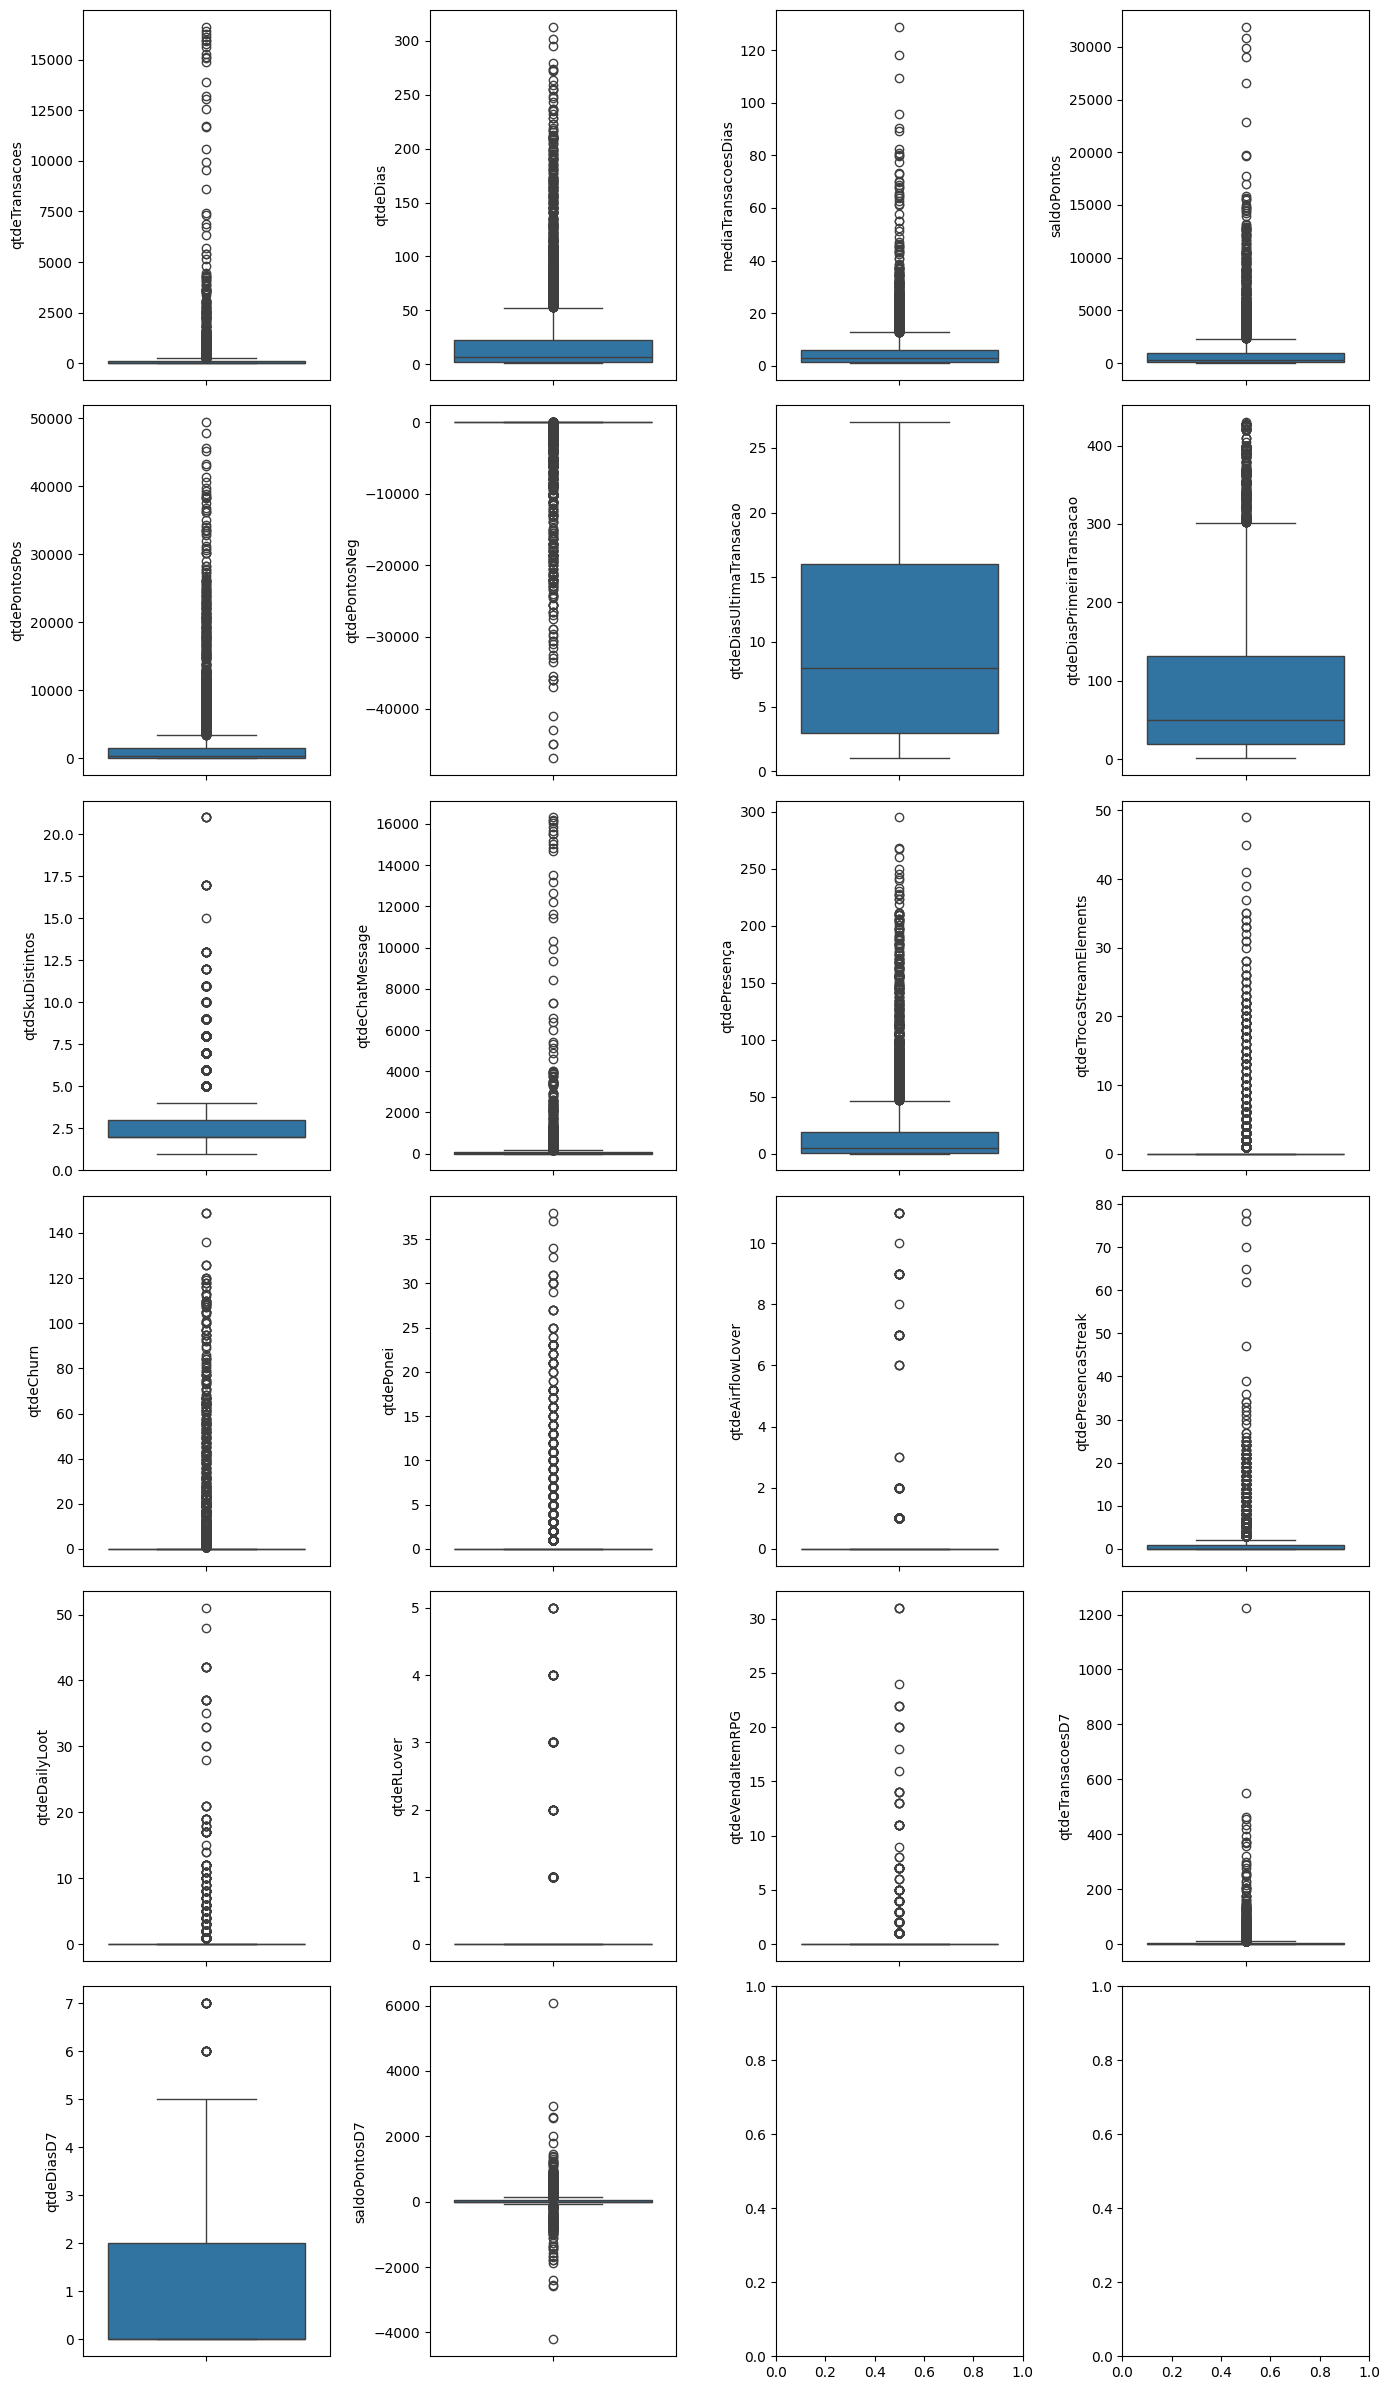

In [61]:
#Podemos observar nos boxplots abaixo que algumas variáveis númericas apresentam uma grande quantidade de "possíveis" outliers
#Precisamos avaliar cada uma dessas variaveis dentro do contexto dos dados para saber se realmente iremos trata-las como outlier
%matplotlib inline
plt.rcParams["figure.figsize"] = [14.00, 24.00]
plt.rcParams["figure.autolayout"] = True
f, axes = plt.subplots(6, 4) #6 linhas e 4 colunas

linha = 0
coluna = 0
for i in variaveis_numericas:
    sns.boxplot(data = df_original, y=i, ax=axes[linha][coluna])
    coluna += 1
    if coluna == 4:
        linha += 1
        coluna = 0            

plt.show()

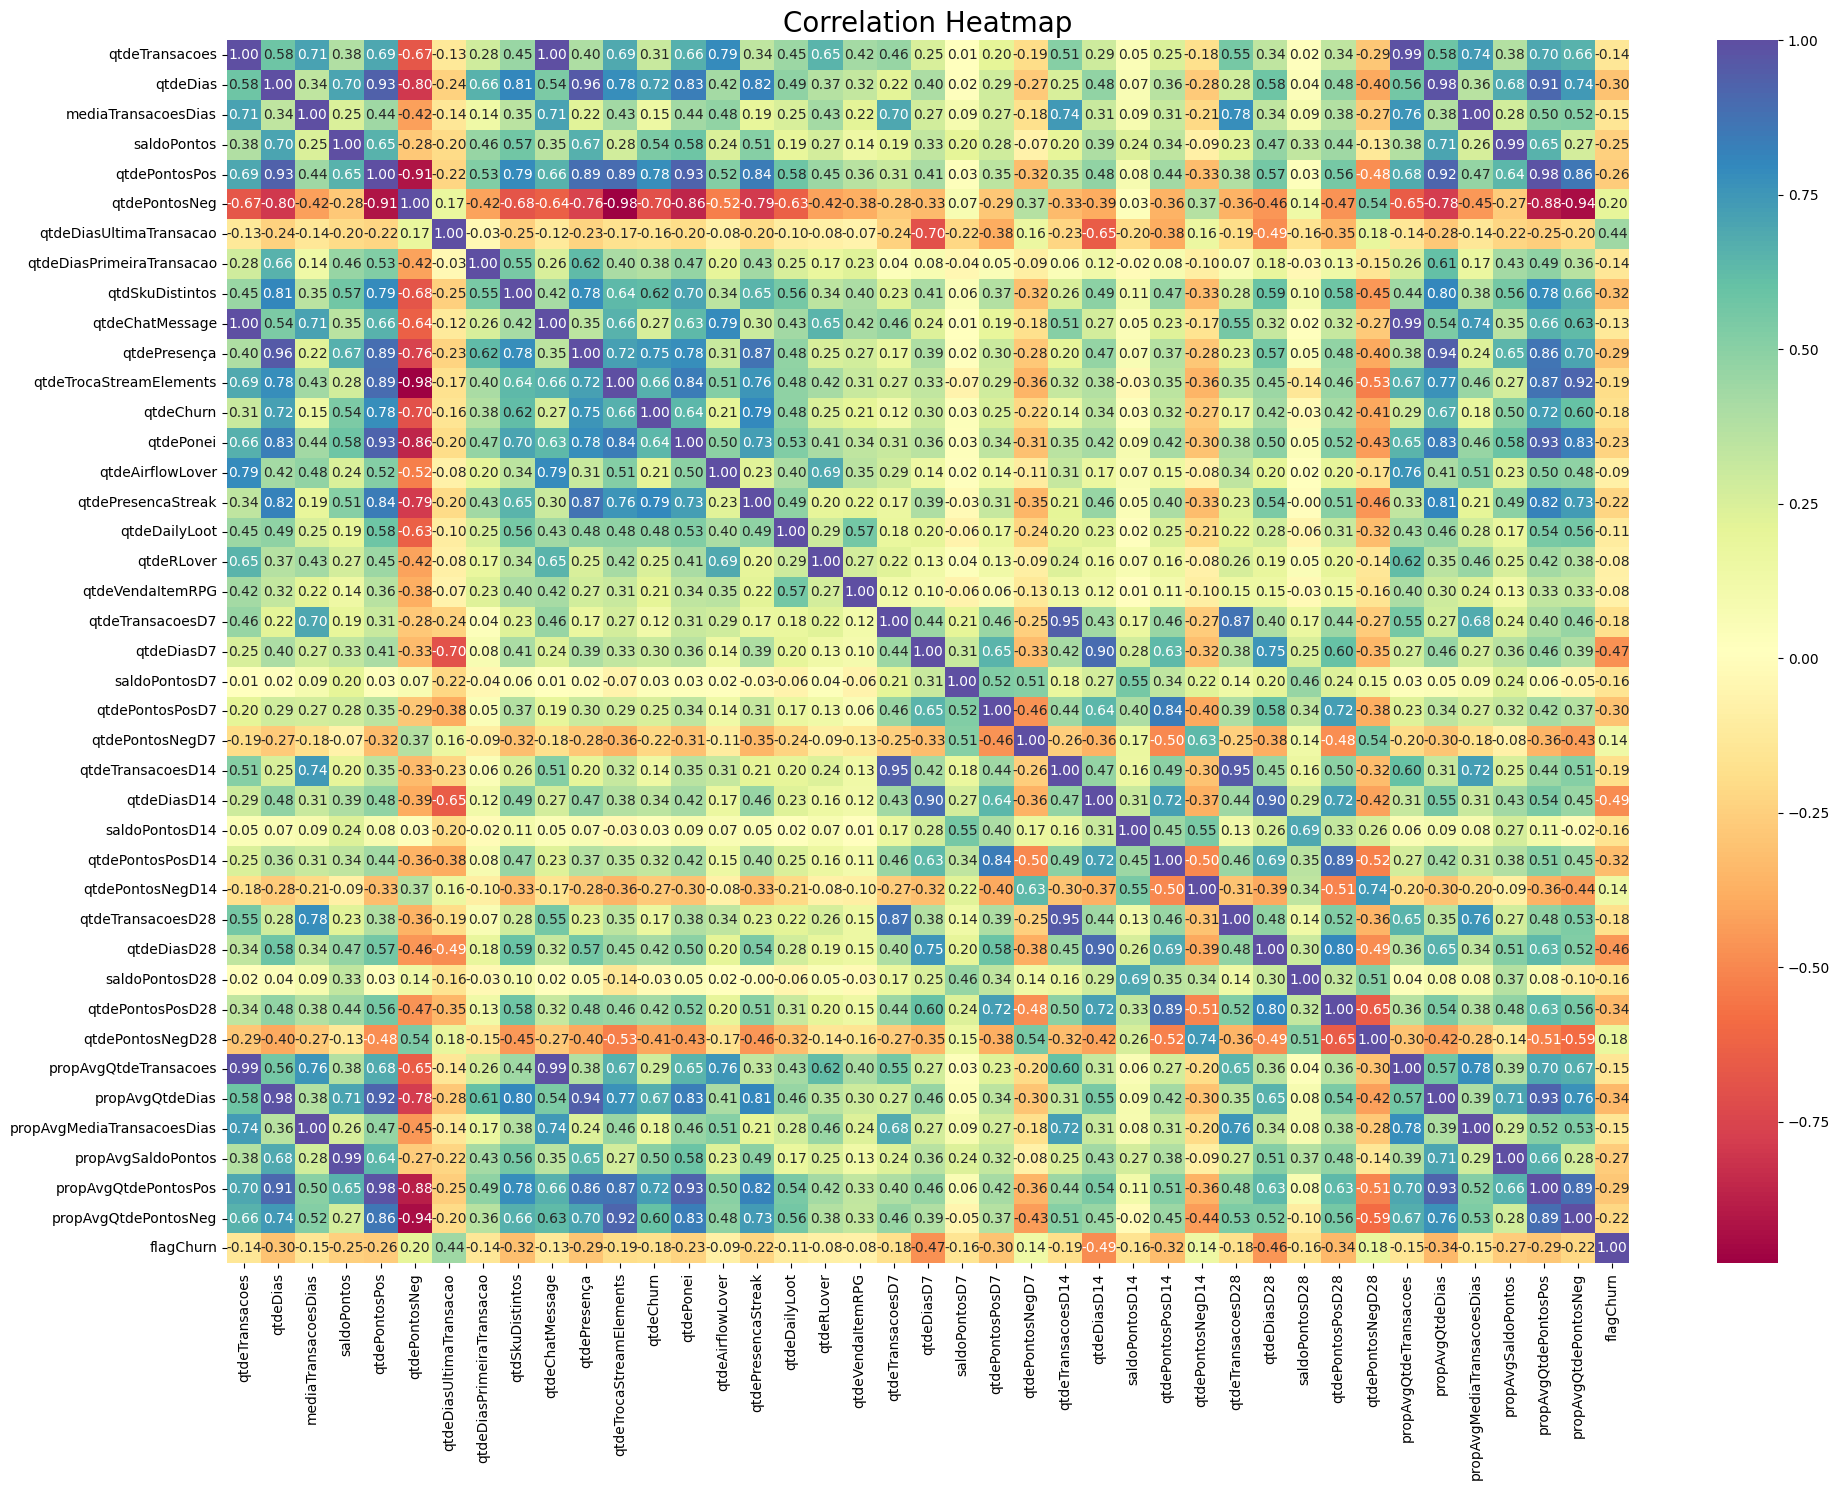

In [62]:
# Select only numeric columns
numeric_df = df_original.select_dtypes(include=np.number)

plt.figure(figsize=(20,15))

corr = numeric_df.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='Spectral',
    fmt='.2f'
)

plt.title("Correlation Heatmap", fontsize=20)

plt.show()

# Treinamento dos modelos 

In [63]:
# Train Test Split
from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_score
from sklearn.metrics import RocCurveDisplay
from sklearn.decomposition import PCA

In [64]:
target_column = "flagChurn"

print("\n")
print("="*70)
print("TARGET COLUMN")
print("="*70)

print(target_column)

print("\nTarget Value Counts")
print(df_original[target_column].value_counts())



TARGET COLUMN
flagChurn

Target Value Counts
flagChurn
0    2908
1    2588
Name: count, dtype: int64


In [65]:
leakage_columns = [
    "flagChurn",
    "dtRef",
    "idUsuario" ,
    "qtdeRLover",
    "qtdeAirflowLover",
    "qtdePontosNegD14",
    "qtdePontosNegD7"
]

X = df_original.drop(columns=leakage_columns)



y = df_original[target_column]

In [66]:
# ============================================================
# IDENTIFICAR COLUNAS CATEGÓRICAS E NUMÉRICAS
# ============================================================

categorical_columns = X.select_dtypes(include=['object']).columns.tolist()

numerical_columns = X.select_dtypes(include=np.number).columns.tolist()

print("\n")
print("="*70)
print("CATEGORICAL COLUMNS")
print("="*70)

print(categorical_columns, len(categorical_columns))

print("\n")
print("="*70)
print("NUMERICAL COLUMNS")
print("="*70)

print(numerical_columns, len(numerical_columns))



CATEGORICAL COLUMNS
[] 0


NUMERICAL COLUMNS
['qtdeTransacoes', 'qtdeDias', 'mediaTransacoesDias', 'saldoPontos', 'qtdePontosPos', 'qtdePontosNeg', 'qtdeDiasUltimaTransacao', 'qtdeDiasPrimeiraTransacao', 'qtdSkuDistintos', 'qtdeChatMessage', 'qtdePresença', 'qtdeTrocaStreamElements', 'qtdeChurn', 'qtdePonei', 'qtdePresencaStreak', 'qtdeDailyLoot', 'qtdeVendaItemRPG', 'qtdeTransacoesD7', 'qtdeDiasD7', 'saldoPontosD7', 'qtdePontosPosD7', 'qtdeTransacoesD14', 'qtdeDiasD14', 'saldoPontosD14', 'qtdePontosPosD14', 'qtdeTransacoesD28', 'qtdeDiasD28', 'saldoPontosD28', 'qtdePontosPosD28', 'qtdePontosNegD28', 'propAvgQtdeTransacoes', 'propAvgQtdeDias', 'propAvgMediaTransacoesDias', 'propAvgSaldoPontos', 'propAvgQtdePontosPos', 'propAvgQtdePontosNeg'] 36


In [67]:
# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("\n")
print("="*70)
print("TRAIN TEST SPLIT")
print("="*70)

print("X_train Shape :", X_train.shape)
print("X_test Shape  :", X_test.shape)

print("y_train Shape :", y_train.shape)
print("y_test Shape  :", y_test.shape)
pca = PCA(n_components=0.95, random_state=42)



TRAIN TEST SPLIT
X_train Shape : (4122, 36)
X_test Shape  : (1374, 36)
y_train Shape : (4122,)
y_test Shape  : (1374,)


In [68]:
# ============================================================
# PREPROCESSING PIPELINES
# ============================================================

# Numerical Pipeline
numerical_transformer = Pipeline(steps=[

    ('imputer', SimpleImputer(strategy='median')),

    ('scaler', StandardScaler())

])

# Categorical Pipeline
categorical_transformer = Pipeline(steps=[

    ('imputer', SimpleImputer(strategy='most_frequent')),

    ('onehot', OneHotEncoder(handle_unknown='ignore'))

])

# Combine Pipelines
preprocessor = ColumnTransformer(transformers=[

    ('num', numerical_transformer, numerical_columns),

    ('cat', categorical_transformer, categorical_columns)

])



LOGISTIC REGRESSION

Cross-Validation Scores : [0.7797, 0.7676, 0.7524, 0.6796, 0.7039, 0.7549, 0.7597, 0.7913, 0.7427, 0.7379]
Média                   : 0.7470
Desvio padrão           : 0.0319

Accuracy Score : 0.7380


CLASSIFICATION REPORT
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.79      0.69      0.73       727
           1       0.69      0.80      0.74       647

    accuracy                           0.74      1374
   macro avg       0.74      0.74      0.74      1374
weighted avg       0.74      0.74      0.74      1374



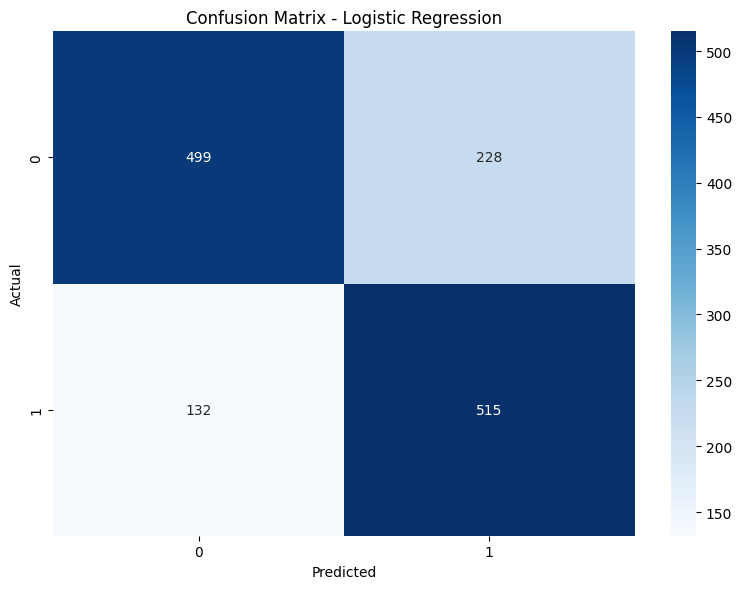

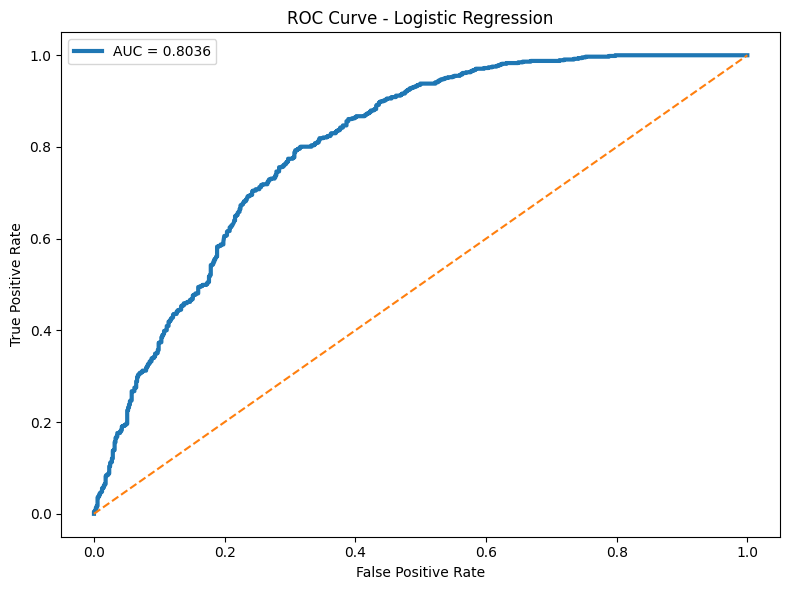



NAIVE BAYES


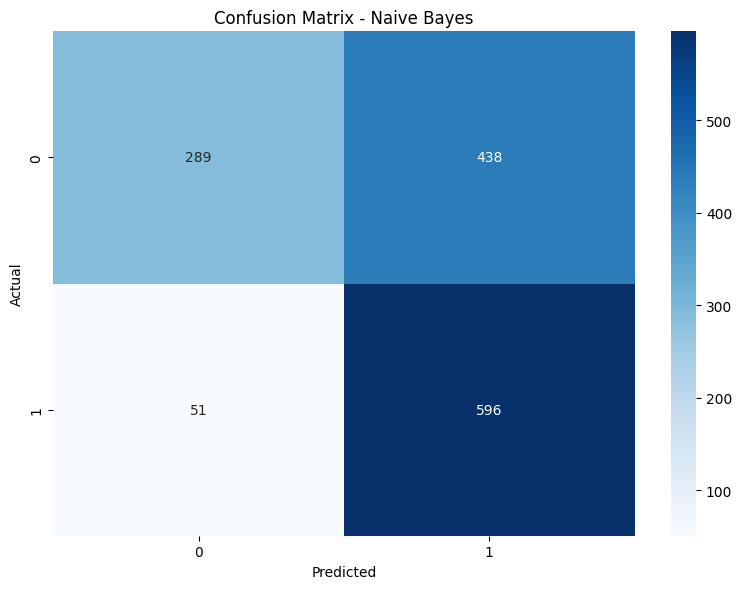

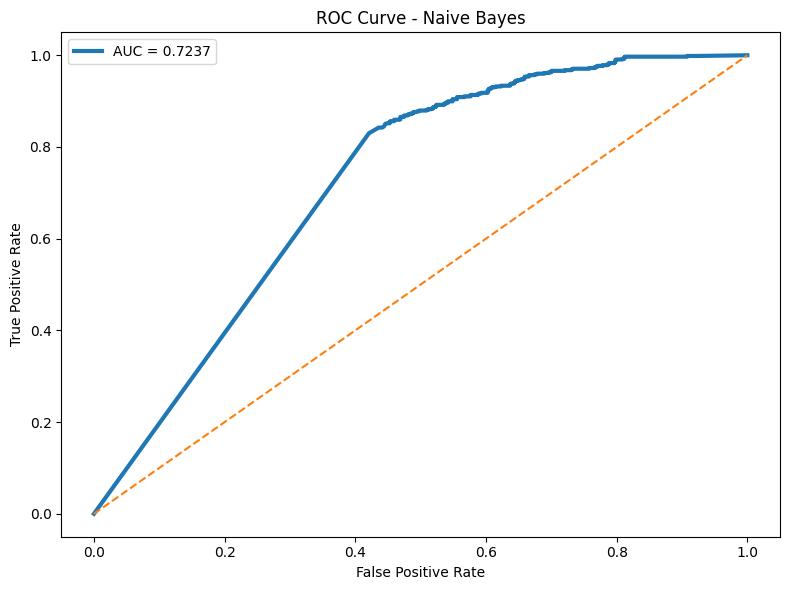



DECISION TREE

Cross-Validation Scores : [0.7022, 0.7070, 0.6869, 0.6553, 0.6650, 0.6383, 0.6820, 0.7136, 0.6359, 0.6383]
Média                   : 0.6725
Desvio padrão           : 0.0284

Accuracy Score : 0.6485


CLASSIFICATION REPORT
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.67      0.67      0.67       727
           1       0.63      0.63      0.63       647

    accuracy                           0.65      1374
   macro avg       0.65      0.65      0.65      1374
weighted avg       0.65      0.65      0.65      1374



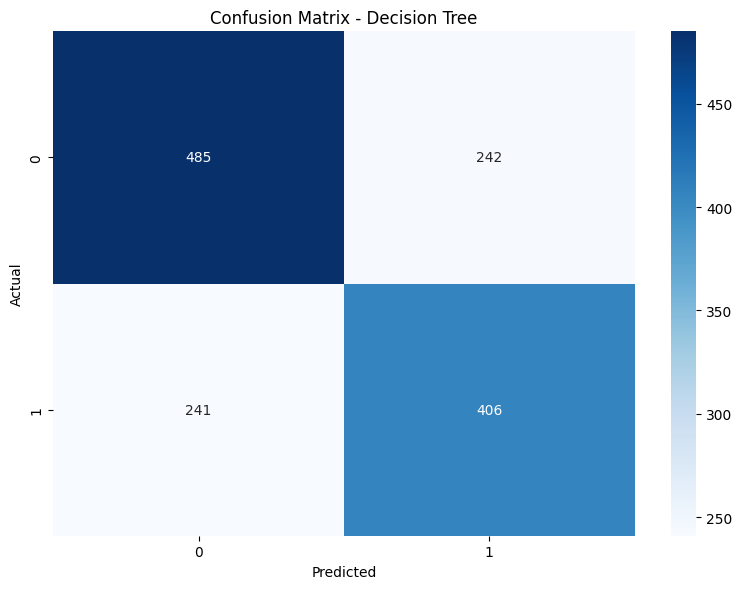

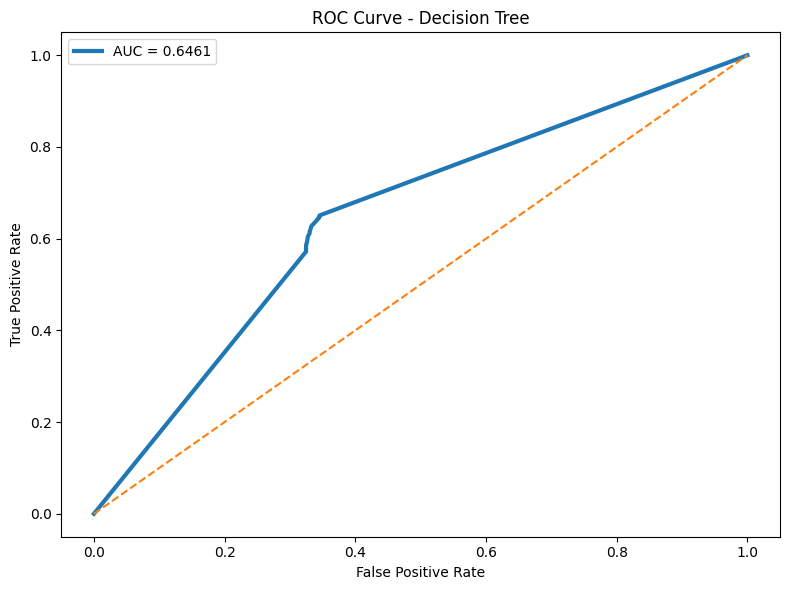



RANDOM FOREST

Cross-Validation Scores : [0.7651, 0.7409, 0.7233, 0.7087, 0.6942, 0.7379, 0.7427, 0.7646, 0.7354, 0.6820]
Média                   : 0.7295
Desvio padrão           : 0.0262

Accuracy Score : 0.7009


CLASSIFICATION REPORT
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.72      0.70      0.71       727
           1       0.68      0.70      0.69       647

    accuracy                           0.70      1374
   macro avg       0.70      0.70      0.70      1374
weighted avg       0.70      0.70      0.70      1374



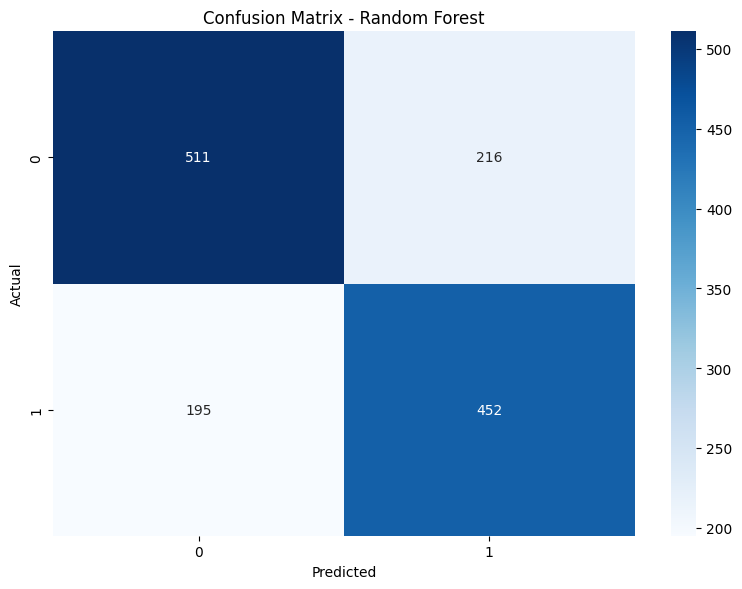

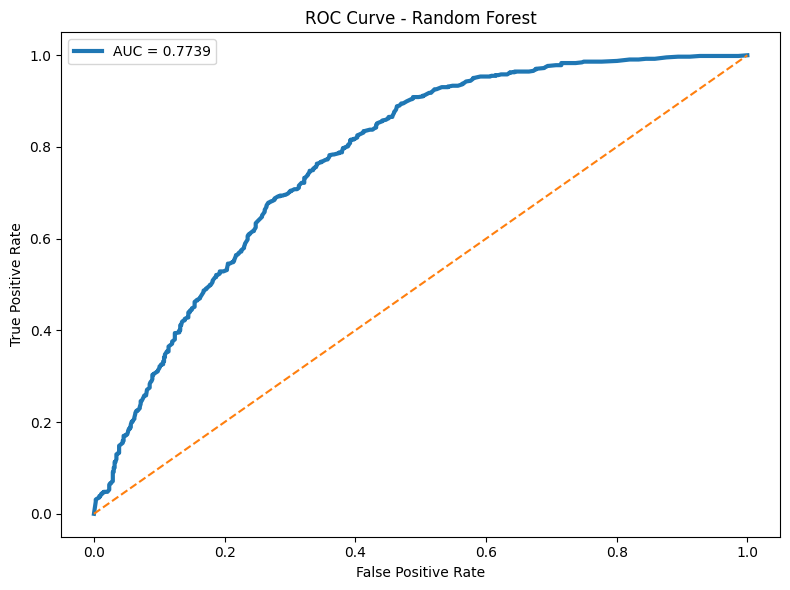



GRADIENT BOOSTING

Cross-Validation Scores : [0.7627, 0.7627, 0.7524, 0.7015, 0.7112, 0.7549, 0.7767, 0.7816, 0.7330, 0.7233]
Média                   : 0.7460
Desvio padrão           : 0.0260

Accuracy Score : 0.7271


CLASSIFICATION REPORT
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.77      0.69      0.73       727
           1       0.69      0.77      0.73       647

    accuracy                           0.73      1374
   macro avg       0.73      0.73      0.73      1374
weighted avg       0.73      0.73      0.73      1374



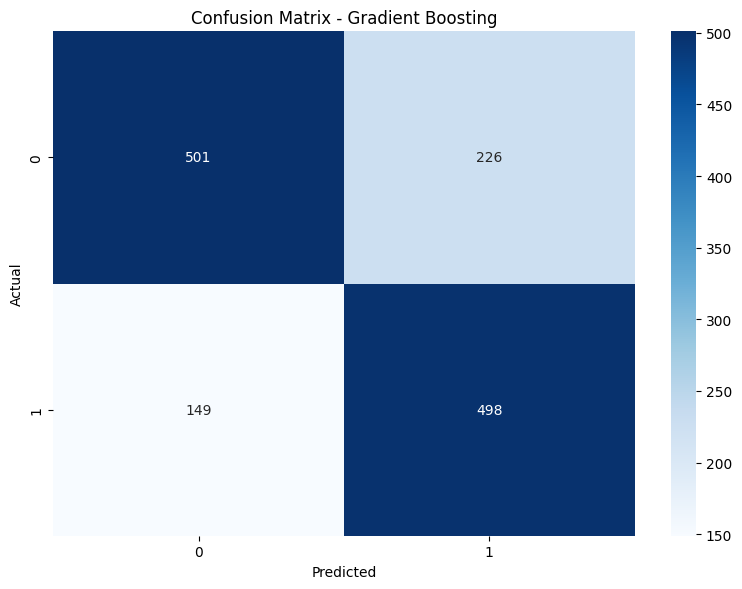

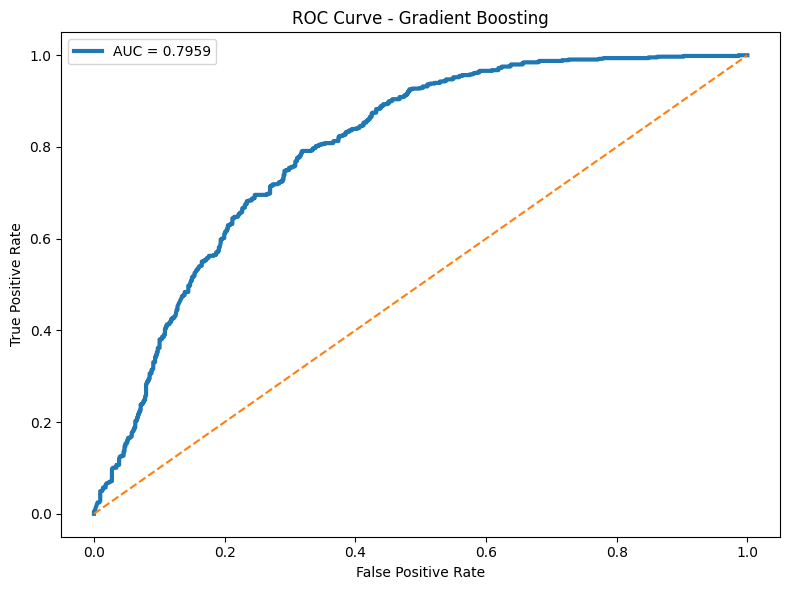



KNN

Cross-Validation Scores : [0.7676, 0.7191, 0.7039, 0.6748, 0.6650, 0.7184, 0.7451, 0.7573, 0.6942, 0.6917]
Média                   : 0.7137
Desvio padrão           : 0.0327

Accuracy Score : 0.7162


CLASSIFICATION REPORT
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.75      0.70      0.72       727
           1       0.68      0.74      0.71       647

    accuracy                           0.72      1374
   macro avg       0.72      0.72      0.72      1374
weighted avg       0.72      0.72      0.72      1374



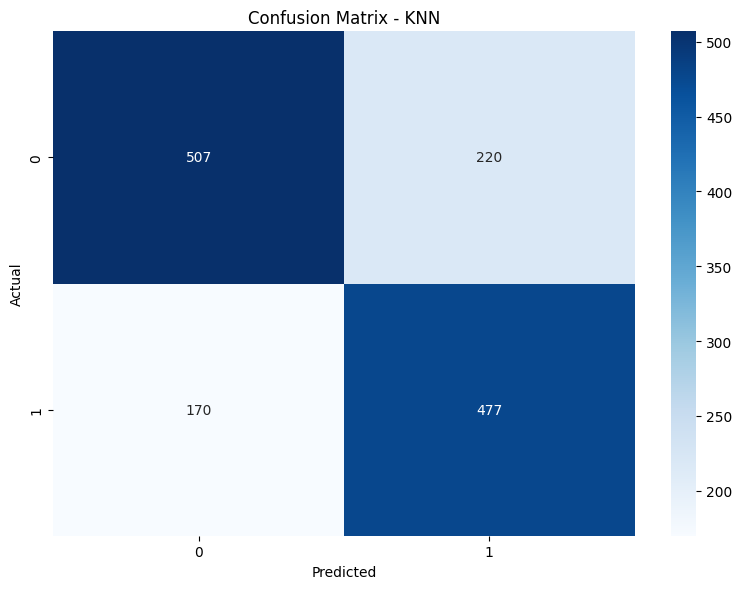

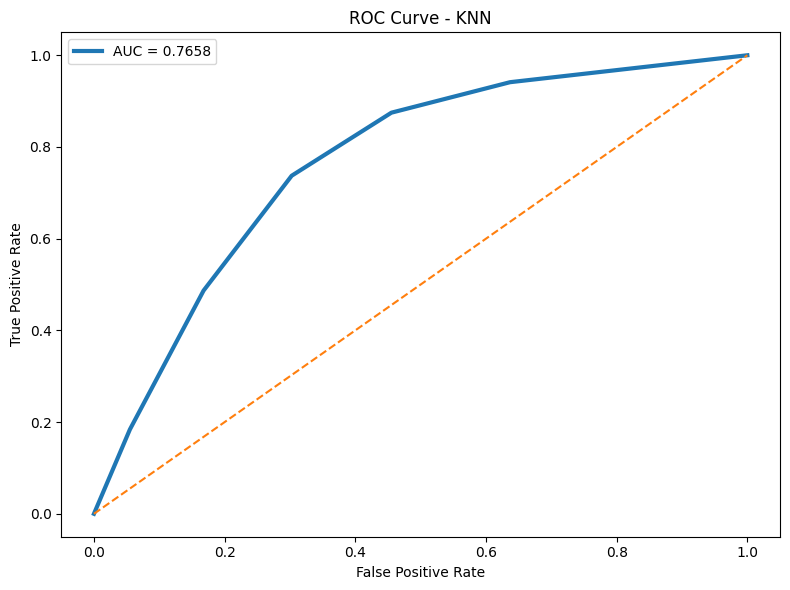



SVM

Cross-Validation Scores : [0.7579, 0.7530, 0.7379, 0.6820, 0.7039, 0.7670, 0.7573, 0.7864, 0.7549, 0.7184]
Média                   : 0.7419
Desvio padrão           : 0.0300

Accuracy Score : 0.7234


CLASSIFICATION REPORT
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.80      0.64      0.71       727
           1       0.67      0.82      0.74       647

    accuracy                           0.72      1374
   macro avg       0.73      0.73      0.72      1374
weighted avg       0.74      0.72      0.72      1374



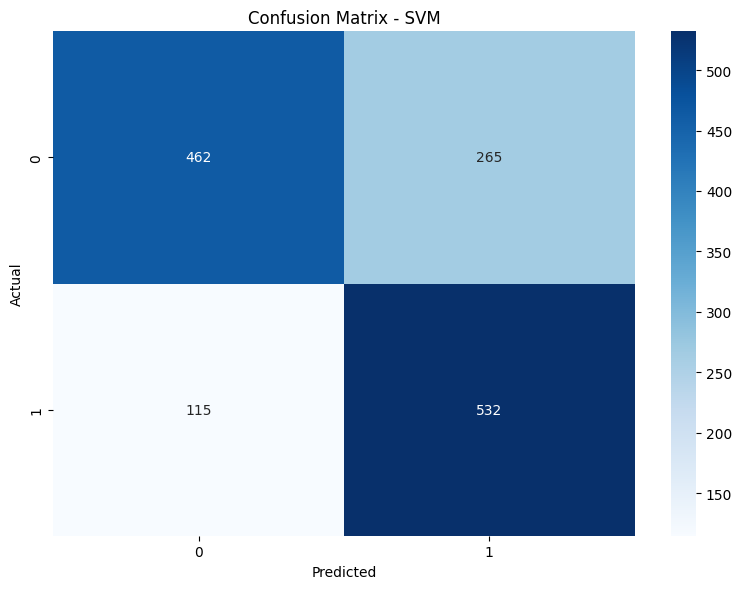

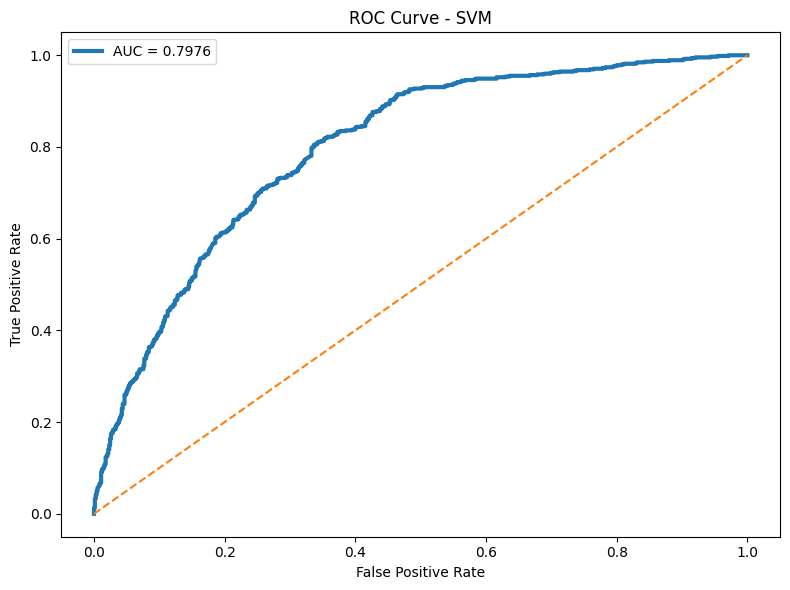



FINAL MODEL COMPARISON
                 Model  Accuracy   ROC_AUC
0  Logistic Regression  0.737991  0.803639
1          Naive Bayes  0.737991  0.723748
4    Gradient Boosting  0.727074  0.795901
6                  SVM  0.723435  0.797582
5                  KNN  0.716157  0.765804
3        Random Forest  0.700873  0.773913
2        Decision Tree  0.648472  0.646117


C:\Users\gugaa\AppData\Local\Temp\ipykernel_19052\2183772478.py:211: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


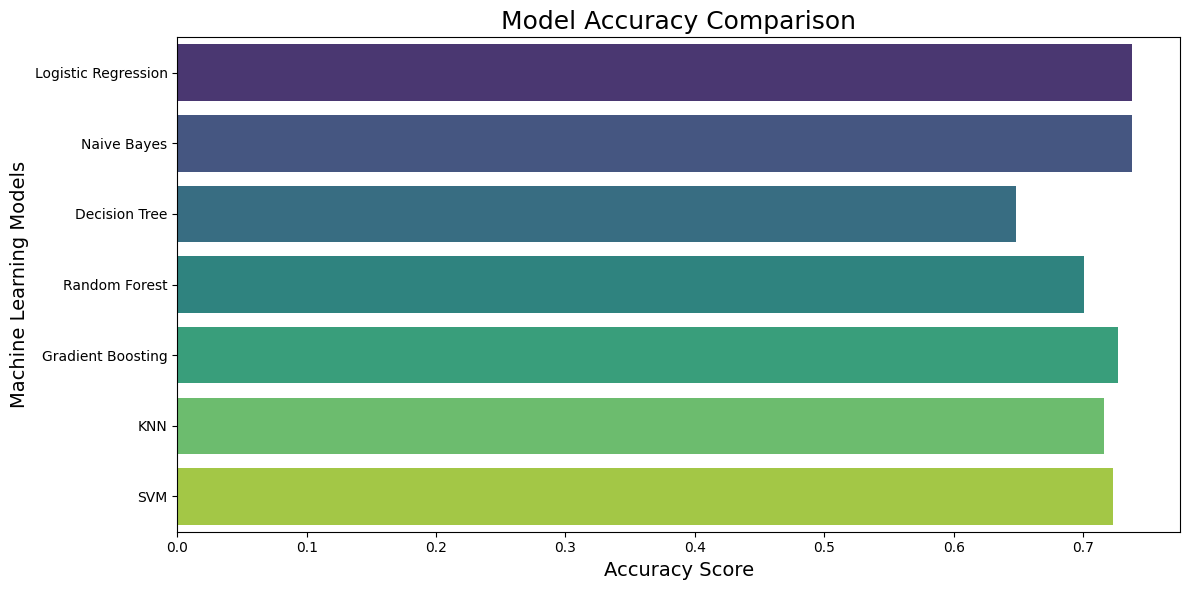

C:\Users\gugaa\AppData\Local\Temp\ipykernel_19052\2183772478.py:232: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


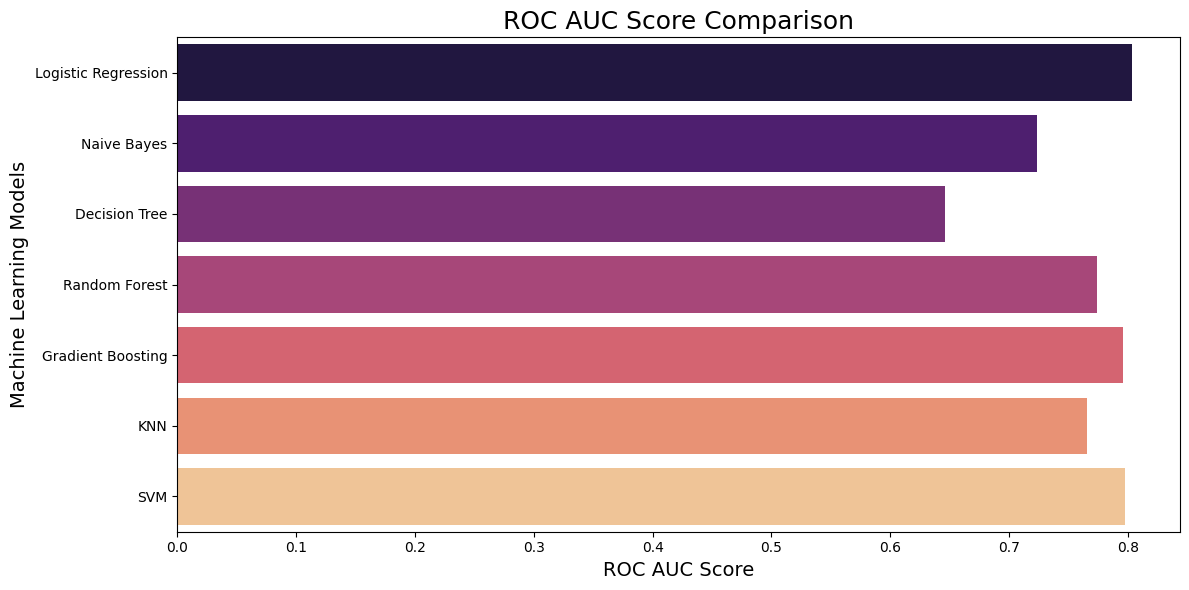



BEST MODEL
Best Model      : Logistic Regression
Best Accuracy   : 0.7380
Best ROC AUC    : 0.8036


RANDOM FOREST FEATURE IMPORTANCE
                            Feature  Importance
6      num__qtdeDiasUltimaTransacao    0.067058
31             num__propAvgQtdeDias    0.056829
22                 num__qtdeDiasD14    0.056234
7    num__qtdeDiasPrimeiraTransacao    0.053411
18                  num__qtdeDiasD7    0.050356
34        num__propAvgQtdePontosPos    0.048494
30       num__propAvgQtdeTransacoes    0.047365
33          num__propAvgSaldoPontos    0.044730
32  num__propAvgMediaTransacoesDias    0.040196
24            num__qtdePontosPosD14    0.039710
26                 num__qtdeDiasD28    0.038424
17            num__qtdeTransacoesD7    0.036204
28            num__qtdePontosPosD28    0.036188
20             num__qtdePontosPosD7    0.035799
21           num__qtdeTransacoesD14    0.033728
4                num__qtdePontosPos    0.031305
3                  num__saldoPontos    0.031006


C:\Users\gugaa\AppData\Local\Temp\ipykernel_19052\2183772478.py:314: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


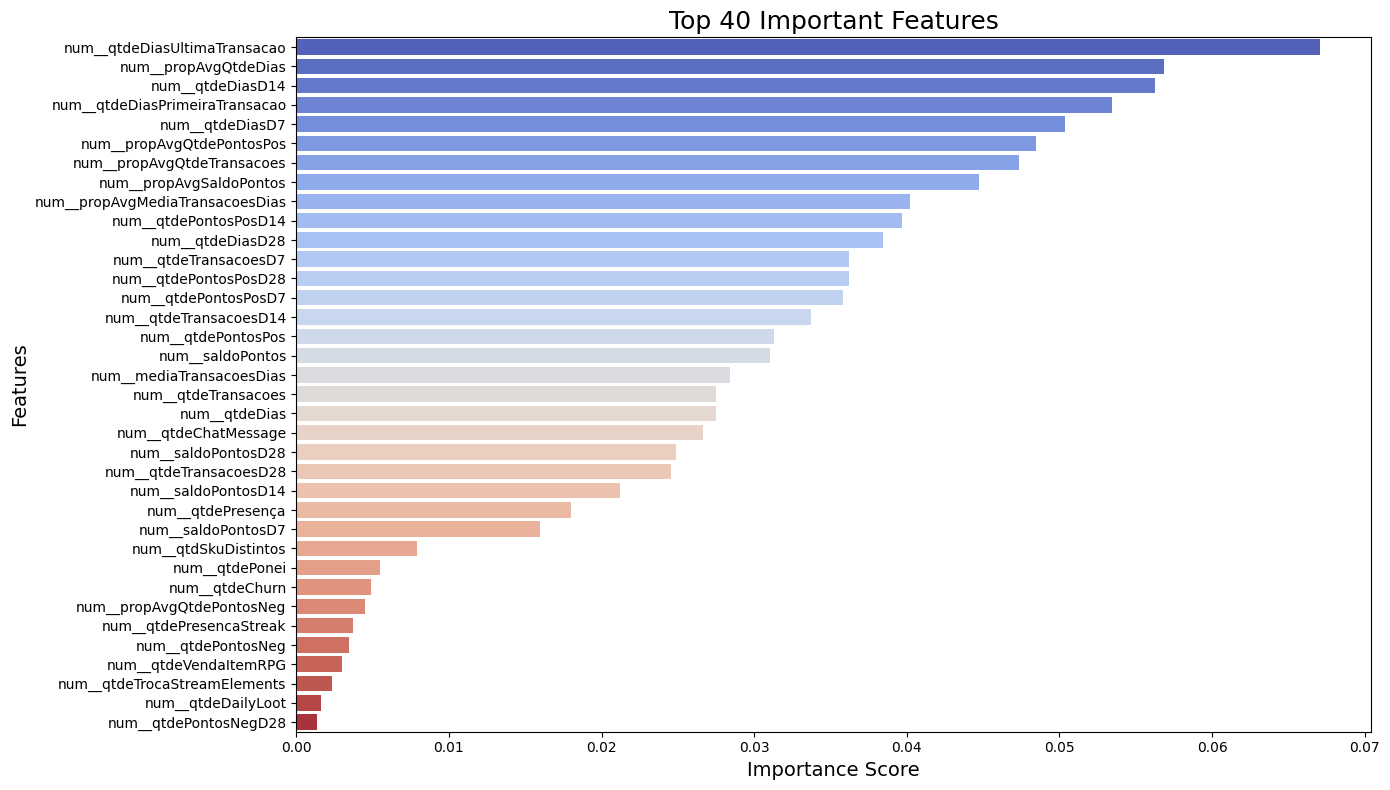



MACHINE LEARNING PIPELINE COMPLETED SUCCESSFULLY


In [70]:
# ============================================================
# MACHINE LEARNING MODELS
# ============================================================

models = {

    "Logistic Regression": LogisticRegression(max_iter=5000),

    "Naive Bayes": GaussianNB(),

    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(random_state=42),

    "KNN": KNeighborsClassifier(),

    "SVM": SVC(
        probability=True,
        random_state=42
    )
}

# ============================================================
# STORE RESULTS
# ============================================================

results = []

# ============================================================
# TRAIN & EVALUATE MODELS
# ============================================================

for model_name, model in models.items():

    print("\n")
    print("="*80)
    print(model_name.upper())
    print("="*80)

    # ========================================================
    # SPECIAL HANDLING FOR NAIVE BAYES
    # ========================================================

    if model_name == "Naive Bayes":

        # Transform data first
        X_train_processed = preprocessor.fit_transform(X_train)
        X_test_processed = preprocessor.transform(X_test)

        X_train_processed = preprocessor.fit_transform(X_train)
        X_test_processed = preprocessor.transform(X_test)

        # Fit model
        model.fit(X_train_processed, y_train)

        # Predictions
        y_pred = model.predict(X_test_processed)

        # Probabilities
        y_prob = model.predict_proba(X_test_processed)

    else:


            # Full pipeline
            pipeline = Pipeline(steps=[
                ('preprocessor', preprocessor),
                ('pca', PCA(n_components=0.95, random_state=42)),
                ('model', model)
            ])

            # Cross-validation
            scores = cross_val_score(pipeline, X_train, y_train, cv=10)

            scores_str = ", ".join([f"{s:.4f}" for s in scores])
            print(f"\nCross-Validation Scores : [{scores_str}]")
            print(f"Média                   : {scores.mean():.4f}")
            print(f"Desvio padrão           : {scores.std():.4f}")

            # Train model
            pipeline.fit(X_train, y_train)

            # Predictions
            y_pred = pipeline.predict(X_test)

            # Prediction probabilities
            y_prob = pipeline.predict_proba(X_test)

            # ==============================================================
            # ACCURACY
            # ==============================================================

            accuracy = accuracy_score(y_test, y_pred)

            print(f"\nAccuracy Score : {accuracy:.4f}")

            # ==============================================================
            # CLASSIFICATION REPORT
            # ==============================================================

            print("\n")
            print("CLASSIFICATION REPORT")
            print("-"*60)

            print(classification_report(y_test, y_pred))

    # ========================================================
    # CONFUSION MATRIX
    # ========================================================

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8,6))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    plt.show()

    # ========================================================
    # ROC CURVE
    # ========================================================

    # Binary or Multi-class handling

    if len(np.unique(y)) == 2:

        # Binary Classification ROC
        auc_score = roc_auc_score(y_test, y_prob[:,1])

        fpr, tpr, thresholds = roc_curve(
            y_test,
            y_prob[:,1]
        )

        plt.figure(figsize=(8,6))

        plt.plot(
            fpr,
            tpr,
            linewidth=3,
            label=f'AUC = {auc_score:.4f}'
        )

        plt.plot([0,1], [0,1], linestyle='--')

        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")

        plt.title(f"ROC Curve - {model_name}")

        plt.legend()

        plt.show()

    else:

        # Multi-class ROC AUC
        auc_score = roc_auc_score(
            y_test,
            y_prob,
            multi_class='ovr'
        )

        print(f"\nMulti-Class ROC AUC Score : {auc_score:.4f}")

    # ========================================================
    # STORE RESULTS
    # ========================================================

    results.append({

        'Model': model_name,
        'Accuracy': accuracy,
        'ROC_AUC': auc_score

    })

# ============================================================
# RESULTS COMPARISON
# ============================================================

results_df = pd.DataFrame(results)

print("\n")
print("="*80)
print("FINAL MODEL COMPARISON")
print("="*80)

print(results_df.sort_values(by='Accuracy', ascending=False))

# ============================================================
# VISUALIZE MODEL ACCURACY
# ============================================================

plt.figure(figsize=(12,6))

sns.barplot(
    x='Accuracy',
    y='Model',
    data=results_df,
    palette='viridis'
)

plt.title("Model Accuracy Comparison", fontsize=18)

plt.xlabel("Accuracy Score", fontsize=14)

plt.ylabel("Machine Learning Models", fontsize=14)

plt.show()

# ============================================================
# VISUALIZE ROC AUC SCORES
# ============================================================

plt.figure(figsize=(12,6))

sns.barplot(
    x='ROC_AUC',
    y='Model',
    data=results_df,
    palette='magma'
)

plt.title("ROC AUC Score Comparison", fontsize=18)

plt.xlabel("ROC AUC Score", fontsize=14)

plt.ylabel("Machine Learning Models", fontsize=14)

plt.show()

# ============================================================
# BEST MODEL
# ============================================================

best_model = results_df.sort_values(
    by='Accuracy',
    ascending=False
).iloc[0]

print("\n")
print("="*80)
print("BEST MODEL")
print("="*80)

print(f"Best Model      : {best_model['Model']}")
print(f"Best Accuracy   : {best_model['Accuracy']:.4f}")
print(f"Best ROC AUC    : {best_model['ROC_AUC']:.4f}")

# ============================================================
# FEATURE IMPORTANCE (RANDOM FOREST)
# ============================================================

print("\n")
print("="*80)
print("RANDOM FOREST FEATURE IMPORTANCE")
print("="*80)

rf_pipeline = Pipeline(steps=[

    ('preprocessor', preprocessor),

    ('model', RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))

])

rf_pipeline.fit(X_train, y_train)

# Get feature names after encoding
preprocessor_fitted = rf_pipeline.named_steps['preprocessor']

# Pega todos os nomes direto do ColumnTransformer (já inclui numéricas + categóricas)
all_features = preprocessor_fitted.get_feature_names_out()

# Get importances
importances = rf_pipeline.named_steps['model'].feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': importances
})

feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
).head(40)

print(feature_importance_df)

# ============================================================
# FEATURE IMPORTANCE PLOT
# ============================================================

plt.figure(figsize=(14,8))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df,
    palette='coolwarm'
)

plt.title("Top 40 Important Features", fontsize=18)

plt.xlabel("Importance Score", fontsize=14)

plt.ylabel("Features", fontsize=14)

plt.show()

# ============================================================
# COMPLETED
# ============================================================

print("\n")
print("="*80)
print("MACHINE LEARNING PIPELINE COMPLETED SUCCESSFULLY")
print("="*80)